In [1]:
import pandas as pd
import numpy as np
import akshare as ak
import pdfplumber
import os
import re
from collections import Counter
import jieba
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# 导入可视化库
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.family'] = 'sans-serif'       # 全局字体类别 
plt.rcParams['font.sans-serif'] = ['SimHei']     # 具体字体：黑体 
plt.rcParams['axes.unicode_minus'] = False       # 解决负号无法显示的问题

C:\Users\Lenovo\miniconda3\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 第一步：导入股票数据、财务数据(三张表）、核心宏观数据
### 注意，先定义好股票代码和时间段
### 财务数据和宏观数据只能先导入全市场数据才能进行筛选

In [2]:
# 从新浪接口获取某只股票的历史数据（包含日期）

# 基本参数，包括日期范围和股票代码
stock_code = "688981"      # 中芯国际 A 股
start_date = "20200101"
end_date = "20241231"

stock_code = "688981"  #中芯国际
hist_df = ak.stock_zh_a_hist(symbol=stock_code, period="daily", start_date=start_date, end_date=end_date)
print("历史数据列名:", hist_df.columns.tolist())
print("\n历史数据前5行:")
print(hist_df.head())

# 保存为CSV文件
hist_df.to_csv('annual_reports/stock_data.csv', index=False, encoding='utf-8-sig')

历史数据列名: ['日期', '股票代码', '开盘', '收盘', '最高', '最低', '成交量', '成交额', '振幅', '涨跌幅', '涨跌额', '换手率']

历史数据前5行:
           日期    股票代码     开盘     收盘     最高     最低      成交量           成交额  \
0  2020-07-16  688981  95.00  82.92  95.00  80.00  5522480  4.797912e+10   
1  2020-07-17  688981  79.00  77.06  84.90  75.00  2195971  1.739782e+10   
2  2020-07-20  688981  77.19  79.17  80.51  70.02  2286412  1.700981e+10   
3  2020-07-21  688981  78.30  78.63  82.89  77.77  1619190  1.298126e+10   
4  2020-07-22  688981  77.80  79.57  81.78  77.20  1339817  1.068559e+10   

      振幅     涨跌幅    涨跌额    换手率  
0  54.62  201.97  55.46  53.09  
1  11.94   -7.07  -5.86  21.11  
2  13.61    2.74   2.11  21.98  
3   6.47   -0.68  -0.54  15.57  
4   5.82    1.20   0.94  12.88  


In [3]:
# 清洗股票数据

# 1. 只保留日期 和 收盘价
price_clean = hist_df[["日期", "收盘"]].copy()

# 2. 日期转为 datetime
price_clean["日期"] = pd.to_datetime(price_clean["日期"])

# 3. 按日期排序
price_clean = price_clean.sort_values("日期")

# 4. 设置日期为索引
price_clean = price_clean.set_index("日期")

# 5. 重命名字段
price_clean = price_clean.rename(columns={"收盘": "close"})

# 6. 基础检查
print(price_clean.head())
print(price_clean.tail())
print(price_clean.index.is_monotonic_increasing)
print(f"价格序列长度：{len(price_clean)}")

            close
日期               
2020-07-16  82.92
2020-07-17  77.06
2020-07-20  79.17
2020-07-21  78.63
2020-07-22  79.57
            close
日期               
2024-12-25  97.99
2024-12-26  96.73
2024-12-27  97.51
2024-12-30  99.29
2024-12-31  94.62
True
价格序列长度：1084


In [4]:
# 财务数据的报告期有5年
report_dates = ["20201231", "20211231", "20221231", "20231231", "20241231"]

In [5]:
# 导入资产负债表数据

balance_list = []

for date in report_dates:
    # 取“全市场”资产负债表
    df_all = ak.stock_zcfz_em(date=date)

    # 筛选中芯国际
    df_one = df_all[df_all["股票代码"] == stock_code].copy()

    # 加报告期
    df_one["报告期"] = date

    balance_list.append(df_one)

balance_df = pd.concat(balance_list, ignore_index=True)

print("资产负债表前5行：")
print(balance_df.head())

print("\n资产负债表字段名：")
print(balance_df.columns)

  0%|          | 0/11 [00:00<?, ?it/s]

ChunkedEncodingError: Response ended prematurely

In [ ]:
# 保存资产负债表（5年）
balance_df.to_csv("annual_reports/balance_5y.csv",index=False,encoding="utf-8-sig")
print("资产负债表已保存：annual_reports/balance_5y.csv")

In [ ]:
# 导入利润表

income_list = []

for date in report_dates:
    df_all = ak.stock_lrb_em(date=date)  # 全市场利润表（该报告期）
    df_all["股票代码"] = df_all["股票代码"].astype(str)

    df_one = df_all[df_all["股票代码"] == stock_code].copy()
    df_one["报告期"] = date
    income_list.append(df_one)

income_df = pd.concat(income_list, ignore_index=True)

print("利润表前5行：")
print(income_df.head())
print("\n利润表字段名：")
print(income_df.columns)

income_df.to_csv("annual_reports/income_lrb_5y.csv", index=False, encoding="utf-8-sig")
print("\n已保存：annual_reports/income_lrb_5y.csv")

In [16]:
# 现金流量表

cashflow_list = []

for date in report_dates:
    df_all = ak.stock_xjll_em(date=date)  # 全市场现金流量表（该报告期）
    df_all["股票代码"] = df_all["股票代码"].astype(str)

    df_one = df_all[df_all["股票代码"] == stock_code].copy()
    df_one["报告期"] = date
    cashflow_list.append(df_one)

cashflow_df = pd.concat(cashflow_list, ignore_index=True)

print("现金流量表前5行：")
print(cashflow_df.head())
print("\n现金流量表字段名：")
print(cashflow_df.columns)

cashflow_df.to_csv("annual_reports/cashflow_xjll_5y.csv", index=False, encoding="utf-8-sig")
print("\n已保存：annual_reports/cashflow_xjll_5y.csv")

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

现金流量表前5行：
     序号    股票代码  股票简称     净现金流-净现金流    净现金流-同比增长  经营性现金流-现金流量净额  \
0  4233  688981  中芯国际  4.856363e+10  1371.974948   1.317429e+10   
1  4714  688981  中芯国际 -9.548444e+09  -119.661717   2.084499e+10   
2  4492  688981  中芯国际 -6.360711e+09    33.384843   3.659121e+10   
3  4594  688981  中芯国际 -4.263306e+09    32.974380   2.304776e+10   
4  4594  688981  中芯国际  1.731679e+09   140.618220   2.265863e+10   

   经营性现金流-净现金流占比  投资性现金流-现金流量净额  投资性现金流-净现金流占比  融资性现金流-现金流量净额  融资性现金流-净现金流占比  \
0      27.127892  -4.850312e+10     -99.875399   8.691107e+10     178.963285   
1     218.307758  -4.322881e+10    -452.731492   1.429355e+10     149.695050   
2     575.269164  -6.946843e+10   -1092.148881   2.326896e+10     365.823223   
3     540.607711  -4.170051e+10    -978.126224   1.572793e+10     368.913960   
4    1308.477437  -3.066929e+10   -1771.072641   9.998953e+09     577.413770   

         公告日期       报告期  
0  2022-03-31  20201231  
1  2023-03-29  20211231  
2  2024-03-29  20221231  
3 

In [23]:
# 下载gdp数据
# 注意：宏观数据通过 AkShare 获取。
# 鉴于相关接口返回的是全历史样本，本文进一步将样本期限定为 2020–2024 年，以保证与公司财务数据和年报文本的时间一致性。

gdp = ak.macro_china_gdp()

# 看一下时间列叫什么（一般是“季度”）
print(gdp.columns)

print(gdp.head())

Index(['季度', '国内生产总值-绝对值', '国内生产总值-同比增长', '第一产业-绝对值', '第一产业-同比增长', '第二产业-绝对值',
       '第二产业-同比增长', '第三产业-绝对值', '第三产业-同比增长'],
      dtype='object')
            季度  国内生产总值-绝对值  国内生产总值-同比增长  第一产业-绝对值  第一产业-同比增长  第二产业-绝对值  \
0  2025年第1-3季度   1015036.1          5.2   58060.8        3.8  364020.0   
1  2025年第1-2季度    660535.8          5.3   31171.8        3.7  239050.2   
2    2025年第1季度    318758.0          5.4   11712.8        3.5  111902.9   
3  2024年第1-4季度   1349083.5          5.0   91413.9        3.5  492087.1   
4  2024年第1-3季度    975357.4          4.8   57363.6        3.4  356492.0   

   第二产业-同比增长  第三产业-绝对值  第三产业-同比增长  
0        4.9  592955.2        5.4  
1        5.3  390313.8        5.5  
2        5.9  195142.3        5.3  
3        5.3  765582.5        5.0  
4        5.4  561501.8        4.7  


In [24]:
# 生成日期列 + 同时保留 GDP 绝对值（累计量）与同比
gdp_a = gdp.copy()

# 1) 先把“季度”复制一份到 date（字符串）
gdp_a["date"] = gdp_a["季度"].astype(str)

# 2) 把不同季度写法，统一替换为季度末日期（最直观、最好讲）
gdp_a["date"] = gdp_a["date"].str.replace("年第1季度",  "-03-31", regex=False)
gdp_a["date"] = gdp_a["date"].str.replace("年第1-2季度", "-06-30", regex=False)
gdp_a["date"] = gdp_a["date"].str.replace("年第1-3季度", "-09-30", regex=False)
gdp_a["date"] = gdp_a["date"].str.replace("年第1-4季度", "-12-31", regex=False)

# 3) 转为日期类型
gdp_a["date"] = pd.to_datetime(gdp_a["date"])

# 4) 同时保留 GDP 绝对值 + 同比（并改列名更清晰）
gdp_a = gdp_a.rename(columns={
    "国内生产总值-绝对值": "GDP",
    "国内生产总值-同比增长": "GDPrate"
})

gdp_a = gdp_a[["date", "GDP", "GDPrate"]].sort_values("date").reset_index(drop=True)

# 5) 保存
gdp_a.to_csv(
    "annual_reports/macro_gdp_2020_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

print(gdp_a.head())
print(gdp_a.tail())

        date       GDP  GDPrate
0 2006-03-31   47831.7     12.4
1 2006-06-30  101247.0     13.1
2 2006-09-30  158067.6     12.7
3 2006-12-31  222578.4     12.7
4 2007-03-31   58080.6     13.6
         date        GDP  GDPrate
74 2024-09-30   975357.4      4.8
75 2024-12-31  1349083.5      5.0
76 2025-03-31   318758.0      5.4
77 2025-06-30   660535.8      5.3
78 2025-09-30  1015036.1      5.2


In [25]:
# 下载cpi数据
cpi = ak.macro_china_cpi()

print(cpi.columns)

print(cpi.head())

Index(['月份', '全国-当月', '全国-同比增长', '全国-环比增长', '全国-累计', '城市-当月', '城市-同比增长',
       '城市-环比增长', '城市-累计', '农村-当月', '农村-同比增长', '农村-环比增长', '农村-累计'],
      dtype='object')
          月份  全国-当月  全国-同比增长  全国-环比增长  全国-累计  城市-当月  城市-同比增长  城市-环比增长  城市-累计  \
0  2025年11月份  100.7      0.7     -0.1  100.0  100.7      0.7     -0.1  100.0   
1  2025年10月份  100.2      0.2      0.2   99.9  100.3      0.3      0.2  100.0   
2  2025年09月份   99.7     -0.3      0.1   99.9   99.8     -0.2      0.0   99.9   
3  2025年08月份   99.6     -0.4      0.0   99.9   99.7     -0.3      0.0  100.0   
4  2025年07月份  100.0      0.0      0.4   99.9  100.0      0.0      0.4  100.0   

   农村-当月  农村-同比增长  农村-环比增长  农村-累计  
0  100.4      0.4      0.0   99.7  
1   99.8     -0.2      0.1   99.7  
2   99.5     -0.5      0.2   99.7  
3   99.4     -0.6      0.1   99.7  
4   99.7     -0.3      0.3   99.7  


In [26]:
# 进行数据处理
# 1) 处理“月份”（2025年11月份 → 2025-11-01）
cpi["date"] = (
    cpi["月份"]
    .astype(str)
    .str.replace("年", "-", regex=False)
    .str.replace("月份", "-01", regex=False)
)

cpi["date"] = pd.to_datetime(cpi["date"])

# 2) 只保留最常用的 CPI 指标（全国同比）
cpi_simple = cpi.rename(columns={
    "全国-同比增长": "CPIrate"
})

cpi_simple = cpi_simple[["date", "CPIrate"]].sort_values("date")

# 3) 筛选最近 5 年（2020–2024）
cpi_5y = cpi_simple[
    (cpi_simple["date"] >= "2020-01-01") &
    (cpi_simple["date"] <= "2024-12-31")
]

# 4) 保存
cpi_5y.to_csv(
    "annual_reports/macro_cpi_2020_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CPI（全国同比，2020–2024）已保存")
print(cpi_5y.head())

CPI（全国同比，2020–2024）已保存
         date  CPIrate
70 2020-01-01      5.4
69 2020-02-01      5.2
68 2020-03-01      4.3
67 2020-04-01      3.3
66 2020-05-01      2.4


## 第二步：进行数据的初步分析，具体包括：
### 1.计算股票的对数收益率和波动率
### 2.可视化
### 3.可视化对比不同年份的财务指标变化（可以选择某个指标分析）
### 4.对齐股票收益率数据、财务数据、宏观数据

In [27]:
# 计算对数收益率

# 复制一份数据，避免影响原始 price_clean

final_df = price_clean.copy().sort_index()

# 1. 计算对数收益率
final_df["log_ret"] = np.log(final_df["close"]).diff()

# 看一眼结果
final_df.head()

,close,log_ret
日期,,
2020-07-16,82.92,NaN
2020-07-17,77.06,-0.073292
2020-07-20,79.17,0.027013
2020-07-21,78.63,-0.006844
2020-07-22,79.57,0.011884


In [28]:
# 计算波动率

# 2. 计算 20 日滚动年化波动率
window = 20        # 20 个交易日
trading_days = 252 # 一年交易日数

# 20日滚动年化波动率
window = 20

final_df["volatility"] = (
    final_df["log_ret"]
    .rolling(window)
    .std()
    * np.sqrt(trading_days)
)

# 看一眼结果
final_df.head(25)

,close,log_ret,volatility
日期,,,
2020-07-16,82.92,NaN,NaN
2020-07-17,77.06,-0.073292,NaN
2020-07-20,79.17,0.027013,NaN
2020-07-21,78.63,-0.006844,NaN
2020-07-22,79.57,0.011884,NaN
2020-07-23,78.78,-0.009978,NaN
2020-07-24,71.95,-0.090688,NaN
2020-07-27,70.82,-0.015830,NaN
2020-07-28,72.56,0.024272,NaN


In [29]:
# 可视化，先找出高波动的阶段

# 高波动标记（80%分位）
threshold = final_df["volatility"].quantile(0.8)
# 标记是否处于高波动阶段
final_df["high_vol"] = final_df["volatility"] > threshold

# 看一眼结果
final_df.head(30)

,close,log_ret,volatility,high_vol
日期,,,,
2020-07-16,82.92,NaN,NaN,False
2020-07-17,77.06,-0.073292,NaN,False
2020-07-20,79.17,0.027013,NaN,False
2020-07-21,78.63,-0.006844,NaN,False
2020-07-22,79.57,0.011884,NaN,False
2020-07-23,78.78,-0.009978,NaN,False
2020-07-24,71.95,-0.090688,NaN,False
2020-07-27,70.82,-0.015830,NaN,False
2020-07-28,72.56,0.024272,NaN,False


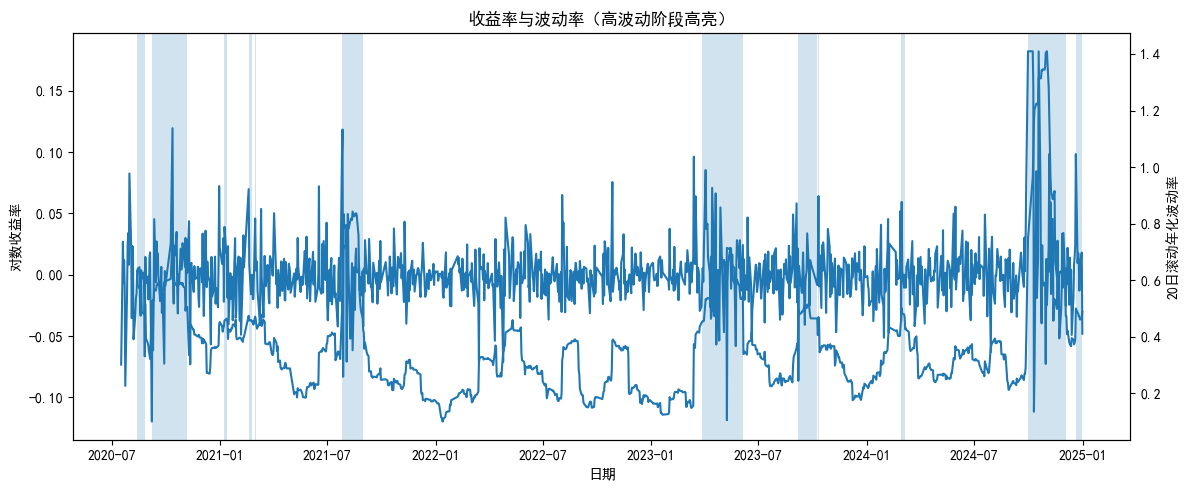

In [30]:
# 画图（收益率+波动率+高亮阶段）

df = final_df.copy()

fig, ax1 = plt.subplots(figsize=(12, 5))

# 左轴：收益率
ax1.plot(df.index, df["log_ret"])
ax1.set_xlabel("日期")
ax1.set_ylabel("对数收益率")

# 右轴：波动率
ax2 = ax1.twinx()
ax2.plot(df.index, df["volatility"])
ax2.set_ylabel("20日滚动年化波动率")

# 高亮：高波动阶段（背景）
ax1.fill_between(
    df.index, 0, 1,
    where=df["high_vol"],
    transform=ax1.get_xaxis_transform(),
    alpha=0.2
)

ax1.set_title("收益率与波动率（高波动阶段高亮）")
plt.tight_layout()
plt.show()

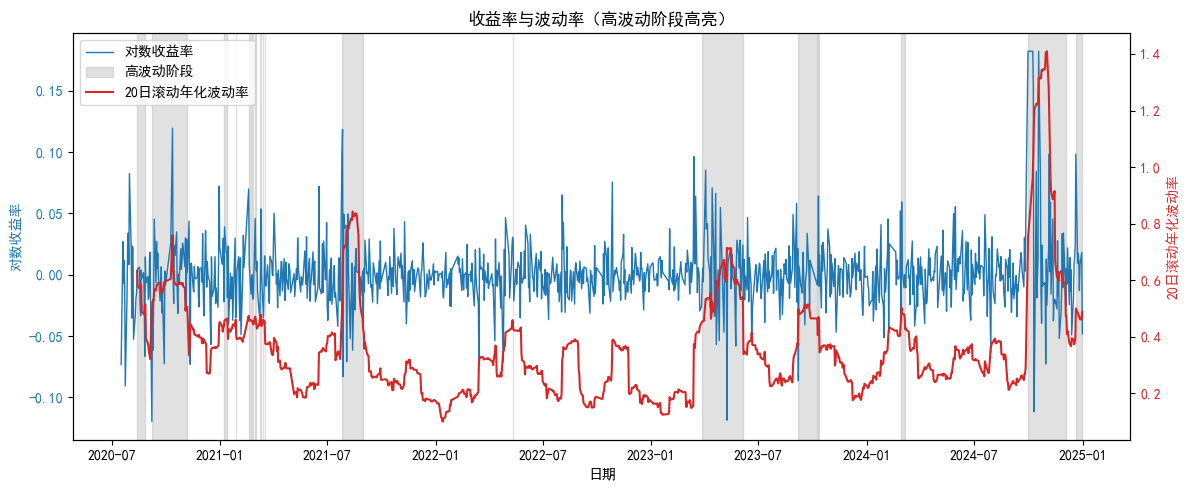

In [31]:
# 把图中线条颜色换种效果
df = final_df.copy()

fig, ax1 = plt.subplots(figsize=(12, 5))

# =========================
# 左轴：收益率（蓝色）
# =========================
ax1.plot(
    df.index,
    df["log_ret"],
    label="对数收益率",
    linewidth=1,
    color="tab:blue"
)
ax1.set_xlabel("日期")
ax1.set_ylabel("对数收益率", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# =========================
# 右轴：波动率（红色）
# =========================
ax2 = ax1.twinx()
ax2.plot(
    df.index,
    df["volatility"],
    label="20日滚动年化波动率",
    linewidth=1.5,
    color="tab:red"
)
ax2.set_ylabel("20日滚动年化波动率", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# =========================
# 高波动阶段：深灰色背景
# =========================
ax1.fill_between(
    df.index,
    0, 1,
    where=df["high_vol"],
    transform=ax1.get_xaxis_transform(),
    color="darkgray",
    alpha=0.35,
    label="高波动阶段"
)

# =========================
# 标题 & 图例
# =========================
ax1.set_title("收益率与波动率（高波动阶段高亮）")

# 合并双轴图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [32]:
# 年度对比：把三表的关键指标按年汇总到一张“年度财务指标表”
# 高波动年份对照：找出某个（或多个）高波动年份，看财务指标是否“同步恶化”

# ==========
# 1) 读入三张表（你上传的文件名）
# ==========
balance = pd.read_csv("annual_reports/balance_5y.csv")
income  = pd.read_csv("annual_reports/income_lrb_5y.csv")
cashflow = pd.read_csv("annual_reports/cashflow_xjll_5y.csv")

# ==========
# 2) 从“报告期”提取年份（20201231 -> 2020）
# ==========
def add_year(df):
    df = df.copy()
    df["year"] = df["报告期"].astype(str).str[:4].astype(int)
    return df

balance = add_year(balance)
income = add_year(income)
cashflow = add_year(cashflow)

# ==========
# 3) 选取关键指标（你这三表的列名就是这些）
# ==========
bal = balance[["year", "资产-总资产", "负债-总负债", "资产负债率", "股东权益合计"]].copy()
inc = income[["year", "营业总收入", "净利润", "营业利润", "利润总额"]].copy()
cf  = cashflow[["year", "经营性现金流-现金流量净额", "投资性现金流-现金流量净额", "融资性现金流-现金流量净额", "净现金流-净现金流"]].copy()

# ==========
# 4) 合并成“年度财务指标表”
# ==========
fin = bal.merge(inc, on="year", how="inner").merge(cf, on="year", how="inner")
fin = fin.sort_values("year").reset_index(drop=True)

# ==========
# 5) 增加几个常用派生指标（简单但很有用）
# ==========
fin["净利率"] = fin["净利润"] / fin["营业总收入"]
fin["经营现金流/净利润"] = fin["经营性现金流-现金流量净额"] / fin["净利润"]

# ==========
# 6) 计算同比变化（和上一年相比）
# ==========
cols_to_yoy = [
    "营业总收入", "净利润", "资产-总资产", "负债-总负债",
    "经营性现金流-现金流量净额", "投资性现金流-现金流量净额",
    "净利率", "资产负债率"
]
for c in cols_to_yoy:
    fin[c + "_YoY"] = fin[c].pct_change()

print("年度财务指标表（核心列）预览：")
show_cols = ["year",
             "营业总收入","净利润","净利率",
             "资产-总资产","负债-总负债","资产负债率",
             "经营性现金流-现金流量净额","投资性现金流-现金流量净额",
             "经营现金流/净利润"]
print(fin[show_cols])

年度财务指标表（核心列）预览：
   year         营业总收入           净利润       净利率        资产-总资产        负债-总负债  \
0  2020  2.747071e+10  4.332270e+09  0.157705  2.046017e+11  6.296570e+10   
1  2021  3.563063e+10  1.073310e+10  0.301232  2.299328e+11  6.795798e+10   
2  2022  4.951608e+10  1.213308e+10  0.245033  3.051037e+11  1.033990e+11   
3  2023  4.525042e+10  4.822814e+09  0.106581  3.384632e+11  1.199930e+11   
4  2024  5.779557e+10  3.698665e+09  0.063996  3.534153e+11  1.243075e+11   

       资产负债率  经营性现金流-现金流量净额  投资性现金流-现金流量净额  经营现金流/净利润  
0  30.774776   1.317429e+10  -4.850312e+10   3.040967  
1  29.555580   2.084499e+10  -4.322881e+10   1.942123  
2  33.889783   3.659121e+10  -6.946843e+10   3.015822  
3  35.452289   2.304776e+10  -4.170051e+10   4.778903  
4  35.173211   2.265863e+10  -3.066929e+10   6.126164  


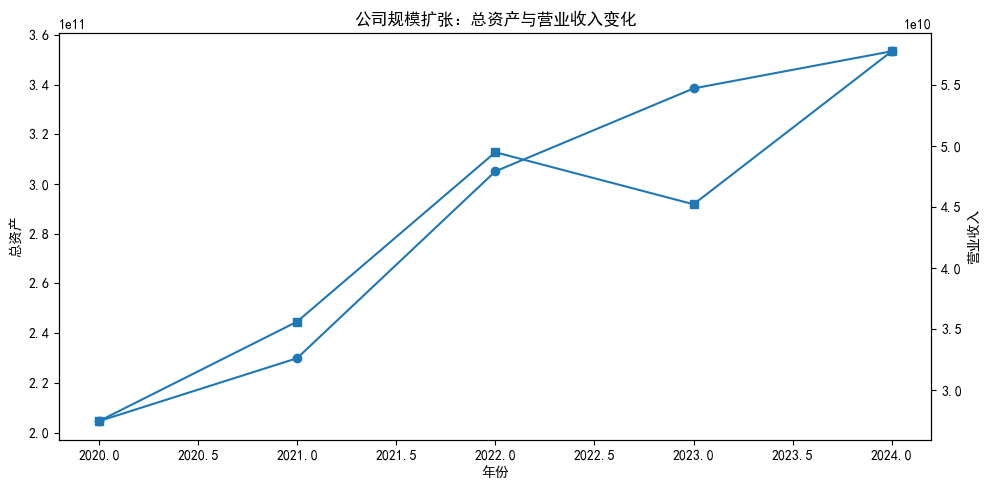

In [33]:
# 可视化
# 总资产 vs 营业收入
df = fin.copy()

fig, ax1 = plt.subplots(figsize=(10, 5))

# 左轴：总资产
ax1.plot(df["year"], df["资产-总资产"], marker="o")
ax1.set_xlabel("年份")
ax1.set_ylabel("总资产")

# 右轴：营业收入
ax2 = ax1.twinx()
ax2.plot(df["year"], df["营业总收入"], marker="s")
ax2.set_ylabel("营业收入")

ax1.set_title("公司规模扩张：总资产与营业收入变化")
plt.tight_layout()
plt.show()

## 公司研究解读模板

### 公司总资产持续扩张，显示出明显的资本开支与扩产特征；
### 营业收入随资产扩张同步变化，表明扩张并非脱离主营业务。

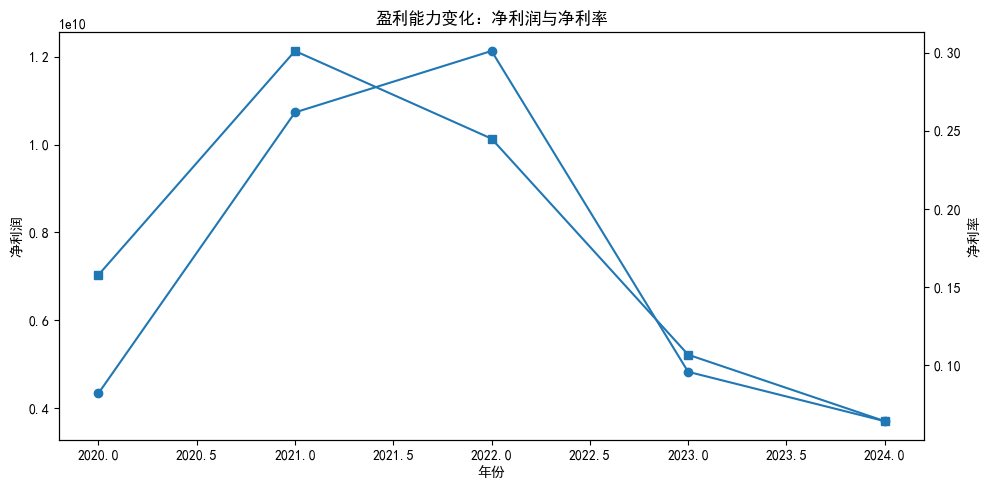

In [34]:
# 盈利能力是否“跟得上扩张”（利润表核心）
fig, ax1 = plt.subplots(figsize=(10, 5))

# 左轴：净利润
ax1.plot(df["year"], df["净利润"], marker="o")
ax1.set_xlabel("年份")
ax1.set_ylabel("净利润")

# 右轴：净利率
ax2 = ax1.twinx()
ax2.plot(df["year"], df["净利率"], marker="s")
ax2.set_ylabel("净利率")

ax1.set_title("盈利能力变化：净利润与净利率")
plt.tight_layout()
plt.show()

## 公司研究解读模板

### 尽管收入规模保持，但净利率波动较大，显示成本结构与行业周期对盈利形成明显制约；
### 当前阶段盈利释放尚未与资产扩张完全匹配。

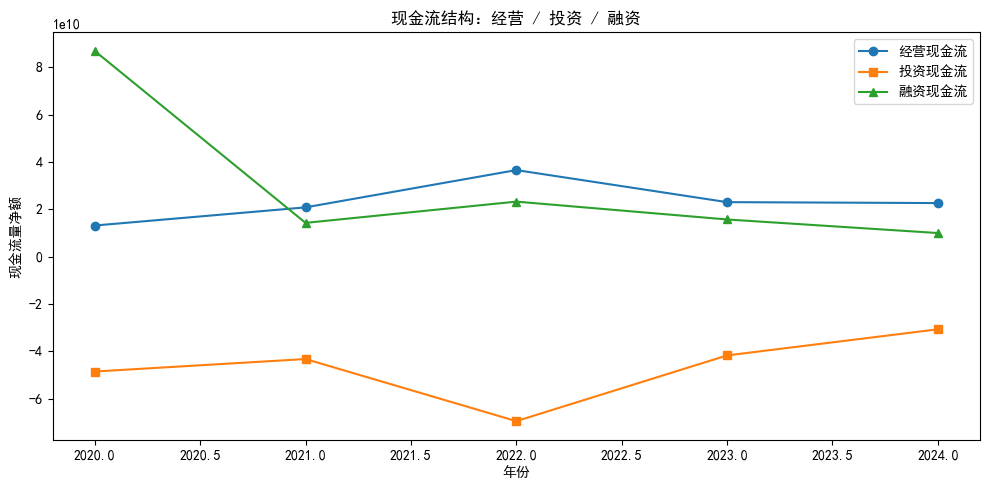

In [35]:
# 现金流是否支持战略扩张（现金流量表核心）
plt.figure(figsize=(10, 5))

plt.plot(df["year"], df["经营性现金流-现金流量净额"], marker="o")
plt.plot(df["year"], df["投资性现金流-现金流量净额"], marker="s")
plt.plot(df["year"], df["融资性现金流-现金流量净额"], marker="^")

plt.xlabel("年份")
plt.ylabel("现金流量净额")
plt.title("现金流结构：经营 / 投资 / 融资")
plt.legend(["经营现金流", "投资现金流", "融资现金流"])

plt.tight_layout()
plt.show()

## 公司研究解读模板（非常关键）

### 投资现金流长期为负，反映持续的资本性支出；
### 经营现金流波动较大，尚不足以完全覆盖投资支出；
### 融资现金流在部分年份起到对冲作用，表明扩张对外部资金与政策环境存在一定依赖。

In [36]:
# 下面对齐各类数据
# 由于股票是日度数据，财务报表是年度数据，宏观变量多为月度/季度数据
# 在公司层面研究中，通常统一对齐到“年度频率”
# 把股票日度数据 → 年度指标

df_stock = final_df.copy()
df_stock["year"] = df_stock.index.year

# 按年汇总（公司研究最常用口径）
stock_year = df_stock.groupby("year").agg(
    avg_ret=("log_ret", "mean"),            # 年均日收益率
    avg_vol=("volatility", "mean"),         # 年均波动率
    high_vol_ratio=("high_vol", "mean")     # 高波动天数占比
).reset_index()

print(stock_year)

   year   avg_ret   avg_vol  high_vol_ratio
0  2020 -0.003173  0.476015        0.434783
1  2021 -0.000354  0.355615        0.168724
2  2022 -0.001046  0.261436        0.004132
3  2023  0.001048  0.345533        0.268595
4  2024  0.002393  0.441930        0.231405


In [37]:
# 宏观数据 → 年度指标
gdp_year = gdp_a.copy()
gdp_year["year"] = gdp_year["date"].dt.year

# 每年只保留最后一个季度（累计口径）
gdp_year = (
    gdp_year
    .sort_values("date")
    .groupby("year")
    .tail(1)
    .reset_index(drop=True)
)

# 只保留最近5年的数据
gdp_5y = gdp_year[
    (gdp_year["year"] >= 2020) &
    (gdp_year["year"] <= 2024)
].copy()

print(gdp_5y)

         date        GDP  GDPrate  year
14 2020-12-31  1034867.6      2.3  2020
15 2021-12-31  1173823.0      8.6  2021
16 2022-12-31  1234029.4      3.1  2022
17 2023-12-31  1294271.7      5.4  2023
18 2024-12-31  1349083.5      5.0  2024


In [38]:
# CPI（月度 → 年度）
cpi_year = cpi_5y.copy()
cpi_year["year"] = cpi_year["date"].dt.year

cpi_year = (
    cpi_year
    .groupby("year")["CPIrate"]
    .mean()
    .reset_index()
)

print(cpi_year)

   year   CPIrate
0  2020  2.508333
1  2021  0.916667
2  2022  1.958333
3  2023  0.241667
4  2024  0.241667


In [39]:
# 生成最终“公司研究主表”
# 以财务数据为核心（公司研究主线）
final_panel = fin.copy()

# 合并股票年度指标
final_panel = final_panel.merge(stock_year, on="year", how="left")

# 合并 GDP
final_panel = final_panel.merge(gdp_year, on="year", how="left")

# 合并 CPI
final_panel = final_panel.merge(cpi_year, on="year", how="left")

print("最终对齐后的分析主表：")
print(final_panel)

最终对齐后的分析主表：
   year        资产-总资产        负债-总负债      资产负债率        股东权益合计         营业总收入  \
0  2020  2.046017e+11  6.296570e+10  30.774776  1.416360e+11  2.747071e+10   
1  2021  2.299328e+11  6.795798e+10  29.555580  1.619748e+11  3.563063e+10   
2  2022  3.051037e+11  1.033990e+11  33.889783  2.017047e+11  4.951608e+10   
3  2023  3.384632e+11  1.199930e+11  35.452289  2.184702e+11  4.525042e+10   
4  2024  3.534153e+11  1.243075e+11  35.173211  2.291078e+11  5.779557e+10   

            净利润          营业利润          利润总额  经营性现金流-现金流量净额  ...  \
0  4.332270e+09  4.498100e+09  4.491068e+09   1.317429e+10  ...   
1  1.073310e+10  1.164522e+10  1.159391e+10   2.084499e+10  ...   
2  1.213308e+10  1.476170e+10  1.475956e+10   3.659121e+10  ...   
3  4.822814e+09  6.905885e+09  6.840418e+09   2.304776e+10  ...   
4  3.698665e+09  6.298647e+09  6.292022e+09   2.265863e+10  ...   

   投资性现金流-现金流量净额_YoY   净利率_YoY  资产负债率_YoY   avg_ret   avg_vol  high_vol_ratio  \
0                NaN       NaN     

宏观指标： GDPrate
市场指标： avg_vol
公司指标： 净利润_YoY
识别出的高波动年份： [2020]


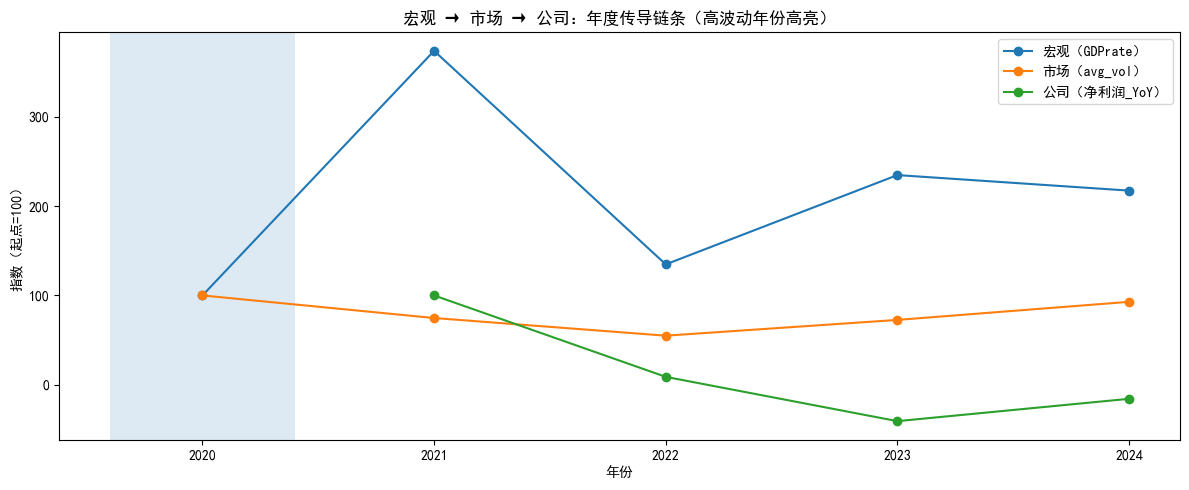

In [40]:
# 一张图讲清“宏观 → 市场 → 公司”的传导

df = final_panel.copy().sort_values("year")

# ==========
# 1) 选三个指标（宏观 / 市场 / 公司）
#    你只要保证这些列在 df 里存在即可
# ==========

# 宏观：优先用 GDPrate（你现在就是这个列名）
macro_col = "GDPrate" if "GDPrate" in df.columns else ("GDP_yoy" if "GDP_yoy" in df.columns else None)

# 市场：优先用 avg_vol（年均波动率），没有就用 high_vol_ratio（高波动天数占比）
market_col = "avg_vol" if "avg_vol" in df.columns else ("high_vol_ratio" if "high_vol_ratio" in df.columns else None)

# 公司：优先用 净利润同比；没有就用 营收同比；再没有就用 净利率同比
company_col = None
for c in ["净利润_YoY", "营业总收入_YoY", "净利率_YoY"]:
    if c in df.columns:
        company_col = c
        break

print("宏观指标：", macro_col)
print("市场指标：", market_col)
print("公司指标：", company_col)

# 检查是否都选到了
if (macro_col is None) or (market_col is None) or (company_col is None):
    raise ValueError("你的 final_panel 里缺少必要列。请把 df.columns 打印出来，我帮你对齐列名。")

# ==========
# 2) 把三个序列都转成“指数=100”（同一尺度更适合一张图讲故事）
#    解释给学生：把每个指标的起点当作100，看相对变化
# ==========

def to_index100(s):
    s = s.astype(float)
    first = s.dropna().iloc[0]
    return (s / first) * 100

plot_df = df[["year", macro_col, market_col, company_col]].copy()
plot_df["宏观指数"] = to_index100(plot_df[macro_col])
plot_df["市场指数"] = to_index100(plot_df[market_col])
plot_df["公司指数"] = to_index100(plot_df[company_col])

# ==========
# 3) 高波动年份：如果你有 high_vol_ratio，就用它自动找“最波动的一年”
#    否则就不高亮
# ==========
high_years = []
if "high_vol_ratio" in df.columns:
    high_year = int(df.sort_values("high_vol_ratio", ascending=False).iloc[0]["year"])
    high_years = [high_year]
    print("识别出的高波动年份：", high_years)

# ==========
# 4) 画一张图：宏观→市场→公司
# ==========
plt.figure(figsize=(12, 5))

plt.plot(plot_df["year"], plot_df["宏观指数"], marker="o")
plt.plot(plot_df["year"], plot_df["市场指数"], marker="o")
plt.plot(plot_df["year"], plot_df["公司指数"], marker="o")

# 高波动年份背景高亮
for y in high_years:
    plt.axvspan(y - 0.4, y + 0.4, alpha=0.15)

plt.xlabel("年份")
plt.ylabel("指数（起点=100）")
plt.title("宏观 → 市场 → 公司：年度传导链条（高波动年份高亮）")
plt.legend([f"宏观（{macro_col}）", f"市场（{market_col}）", f"公司（{company_col}）"])

plt.tight_layout()
plt.show()

## 第三步：文本分析，主要包括：
### 1. 读入五年的年报
### 2. 对年报进行词云图分析
### 3. 对进行情感分析:**管理层讨论与分析（MD&A）**是分析师和研究人员最常用、也是最推荐分析的年报文本部分。

1. 词云图分析 (Word Cloud Analysis)

词云图通过可视化方式，以字体大小展示文本中词语出现的频率。  
价值与适用性:
- 快速识别核心焦点： 年报内容庞杂，词云图能让您一眼看出报告中哪些关键词被管理层最频繁地提及。<br>
例如，如果“创新”、“数字化”、“可持续发展”的字号最大，说明这是公司过去一年的战略重点。
- 捕捉业务重点和趋势：有助于分析师聚焦于公司主营业务、产品、市场以及未来计划中的高频主题，省去人工筛选的繁琐。
- 辅助对比分析：可以将同一家公司不同年份的年报词云图进行对比（纵向），或将同行业不同公司的年报词云图进行对比（横向），以发现战略和关注点的变化。

2. 情感分析 (Sentiment Analysis)  

情感分析（或称文本语气分析）通过算法识别年报文本中所表达的情绪倾向（积极、消极、中性）。<br>
它通常应用于“管理层讨论与分析（MD&A）”、“风险因素”等主观性较强的部分。<br>
价值与适用性<br>
- 揭示管理层态度： 年报是管理层向外界传递公司信息和态度的重要渠道。积极或消极的措辞可能反映了管理层对公司未来业绩或风险的真实看法。
- 学术研究表明： 年报文本语气的积极程度与未来股价崩盘风险的缓解有显著关联。
- 预测市场表现： 文本中积极情感的程度，如对“增长”、“成功”、“优势”的强调，被认为与公司未来的异常股票回报和财务基本面具有预测性关系。
- 风险与信披质量评估：
- 消极词汇的频率可能暗示了管理层正在披露的潜在风险。
- 通过量化文本语气，可以辅助判断信息披露的可信度和印象管理行为。例如，如果财务数据平平，但文本语气却异常乐观，可能需要进一步警惕。

In [41]:
# 识别并读取年报 PDF 文件列表
report_dir = "annual_reports"

pdf_files = sorted([
    os.path.join(report_dir, f)
    for f in os.listdir(report_dir)
    if f.lower().endswith(".pdf")
])

print("识别到的年报文件：")
for f in pdf_files:
    print(f)

识别到的年报文件：
annual_reports\中芯国际2020.pdf
annual_reports\中芯国际2021.pdf
annual_reports\中芯国际2022.pdf
annual_reports\中芯国际2023.pdf
annual_reports\中芯国际2024.pdf


In [42]:
# 用 pdfplumber 打开 PDF（只做“能不能读”的检查）

for pdf_path in pdf_files:
    with pdfplumber.open(pdf_path) as pdf:
        print(f"{os.path.basename(pdf_path)} | 页数：{len(pdf.pages)}")


中芯国际2020.pdf | 页数：256
中芯国际2021.pdf | 页数：269
中芯国际2022.pdf | 页数：244
中芯国际2023.pdf | 页数：234
中芯国际2024.pdf | 页数：222


In [43]:
# 逐页读文本（只读，不清洗、不保存）

# 示例：读取第一份年报全文
pdf_path = pdf_files[0]

texts = []

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            text = re.sub(r"\s+", " ", text)
            texts.append(text)

full_text = "\n".join(texts)

print("字符数：", len(full_text))
print("前300字预览：\n", full_text[:300])

字符数： 271448
前300字预览：
 2020年年度报告 公司代码：688981 公司简称：中芯国际 中芯国际集成电路制造有限公司 2020 年年度报告 1 / 256
2020年年度报告 重要提示 一、 本公司董事会及董事、高级管理人员保证年度报告内容的真实、准确、完整，不存在虚假记 载、误导性陈述或重大遗漏，并承担个别和连带的法律责任。 二、 重大风险提示 公司已在本报告中详细阐述公司在生产经营过程中可能面临的各种风险及应对措施，敬请查 阅本报告“第五节经营情况讨论与分析”之“二、风险因素”。 三、 公司全体董事出席董事会会议。 四、 普华永道中天会计师事务所（特殊普通合伙）为本公司出具了标准无保留意见的审计报告。 五、 公司


In [44]:
# 同时读入五份年报

all_reports_text = {}

for pdf_path in pdf_files:
    year = os.path.basename(pdf_path).replace(".pdf", "")
    texts = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text:
                text = re.sub(r"\s+", " ", text)
                texts.append(text)

    full_text = "\n".join(texts)
    all_reports_text[year] = full_text

    print(year, "字符数：", len(full_text))

中芯国际2020 字符数： 271448
中芯国际2021 字符数： 264069
中芯国际2022 字符数： 220515
中芯国际2023 字符数： 208759
中芯国际2024 字符数： 206743


In [45]:
# PDF → TXT（逐年保存 + 统计报告）

# 1) 输出目录（没有就创建）
out_dir = "annual_reports/data/txt"
os.makedirs(out_dir, exist_ok=True)

stats = []  # 记录每年的统计信息

for pdf_path in pdf_files:
    file_name = os.path.basename(pdf_path)

    # 2) 从文件名里提取年份（简单方法：找连续4位数字）
    m = re.search(r"(20\d{2})", file_name)
    year = m.group(1) if m else file_name.replace(".pdf", "")

    texts = []
    total_pages = 0
    empty_pages = 0

    with pdfplumber.open(pdf_path) as pdf:
        total_pages = len(pdf.pages)

        for page in pdf.pages:
            text = page.extract_text()
            if text and text.strip():
                # 简单清洗：合并空白
                text = re.sub(r"\s+", " ", text)
                texts.append(text)
            else:
                empty_pages += 1

    full_text = "\n".join(texts)

    # 3) 保存为 txt
    txt_path = os.path.join(out_dir, f"{year}.txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(full_text)

    # 4) 统计信息
    word_count = len(full_text)
    success_rate = (total_pages - empty_pages) / total_pages if total_pages > 0 else 0
    empty_ratio = empty_pages / total_pages if total_pages > 0 else 0

    stats.append([year, total_pages, empty_pages, round(empty_ratio, 4), round(success_rate, 4), word_count])

    print(f"✅ {year} 年报已保存：{txt_path} | 字符数={word_count} | 空页比例={empty_ratio:.2%}")

# 5) 输出汇总报告
print("\n===== PDF→TXT 汇总报告 =====")
print("year | 总页数 | 空页数 | 空页比例 | 提取成功率 | 字符数")
for row in stats:
    print(row)

✅ 2020 年报已保存：annual_reports/data/txt\2020.txt | 字符数=271448 | 空页比例=0.00%
✅ 2021 年报已保存：annual_reports/data/txt\2021.txt | 字符数=264069 | 空页比例=0.00%
✅ 2022 年报已保存：annual_reports/data/txt\2022.txt | 字符数=220515 | 空页比例=0.00%
✅ 2023 年报已保存：annual_reports/data/txt\2023.txt | 字符数=208759 | 空页比例=0.00%
✅ 2024 年报已保存：annual_reports/data/txt\2024.txt | 字符数=206743 | 空页比例=0.00%

===== PDF→TXT 汇总报告 =====
year | 总页数 | 空页数 | 空页比例 | 提取成功率 | 字符数
['2020', 256, 0, 0.0, 1.0, 271448]
['2021', 269, 0, 0.0, 1.0, 264069]
['2022', 244, 0, 0.0, 1.0, 220515]
['2023', 234, 0, 0.0, 1.0, 208759]
['2024', 222, 0, 0.0, 1.0, 206743]


In [46]:
# 逐年分词 + 输出 Top30（按年 + 5年合并）
txt_dir = "annual_reports/data/txt"
stop_path = "annual_reports/data/stopwords.txt"

# 1) 读取停用词
with open(stop_path, "r", encoding="utf-8") as f:
    stopwords = set([line.strip() for line in f if line.strip()])

# 2) 找到所有txt
txt_files = sorted([os.path.join(txt_dir, f) for f in os.listdir(txt_dir) if f.endswith(".txt")])
print("识别到的TXT：", [os.path.basename(x) for x in txt_files])

def tokenize(text):
    """中文分词 + 基础清洗（零基础友好版）"""
    text = re.sub(r"[a-zA-Z0-9]+", " ", text)      # 去英数
    text = re.sub(r"[^\u4e00-\u9fa5]+", " ", text) # 只保留中文
    words = jieba.lcut(text)
    # 过滤：停用词、长度<2
    words = [w for w in words if (len(w) >= 2) and (w not in stopwords)]
    return words

year_top = {}          # 每年Top30
all_words = []         # 合并词

for path in txt_files:
    year = os.path.basename(path).replace(".txt", "")
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()

    words = tokenize(text)
    all_words.extend(words)

    top30 = Counter(words).most_common(30)
    year_top[year] = top30

    print(f"\n===== {year} Top30 高频词 =====")
    for w, c in top30:
        print(w, c)

# 合并Top30
print("\n===== 五年合并 Top30 高频词 =====")
top30_all = Counter(all_words).most_common(30)
for w, c in top30_all:
    print(w, c)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Lenovo\AppData\Local\Temp\jieba.cache


识别到的TXT： ['2020.txt', '2021.txt', '2022.txt', '2023.txt', '2024.txt']


Loading model cost 0.301 seconds.
Prefix dict has been built successfully.



===== 2020 Top30 高频词 =====
中芯 459
投资 399
集成电路 381
股权 359
资产 354
股东 334
交易 305
协议 304
企业 268
价值 253
发行 252
服务 239
计划 227
负债 214
项目 212
香港 212
中国 209
上市 199
订立 195
基金 189
证券 180
独立 176
权益 174
南方 173
资金 170
技术 168
国际 165
提供 164
变动 163
租赁 156

===== 2021 Top30 高频词 =====
中芯 395
投资 386
资产 376
股权 363
企业 314
价值 314
股东 305
集成电路 289
交易 280
负债 269
计划 263
发行 218
项目 205
公允 196
变动 192
中国 181
风险 180
确认 180
国际 162
收益 162
权益 161
损益 156
独立 156
股票 146
租赁 146
上市 145
披露 144
影响 142
基金 139
技术 138

===== 2022 Top30 高频词 =====
投资 354
资产 340
价值 285
股东 267
负债 259
企业 242
中芯 217
交易 212
计划 209
集成电路 207
项目 205
变动 198
发行 190
公允 183
股权 181
风险 169
中国 167
确认 162
数量 158
损益 158
股票 157
权益 156
国际 154
收益 149
披露 143
独立 139
承诺 138
租赁 137
金融资产 134
计量 133

===== 2023 Top30 高频词 =====
投资 358
资产 337
股东 288
计划 281
价值 262
变动 210
负债 209
项目 208
企业 197
交易 191
中芯 189
发行 176
集成电路 167
公允 164
中国 161
风险 156
损益 149
股票 148
承诺 146
确认 145
披露 141
股权 139
授予 139
收益 136
租赁 136
权益 135
数量 134
影响 133
国际 132
计量 127

===== 2024 Top30 高频词 =====
中芯 416
集成电

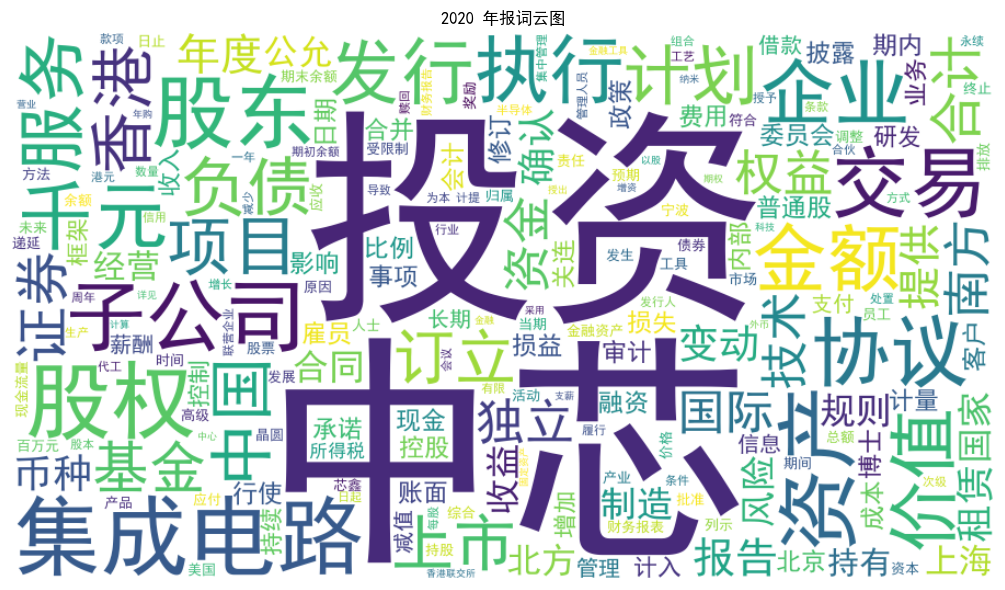

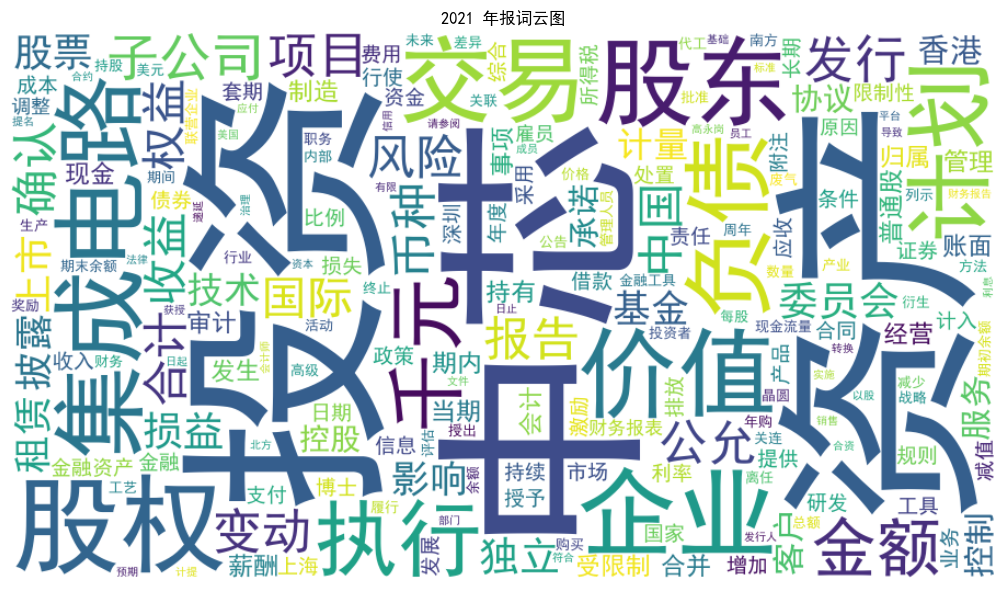

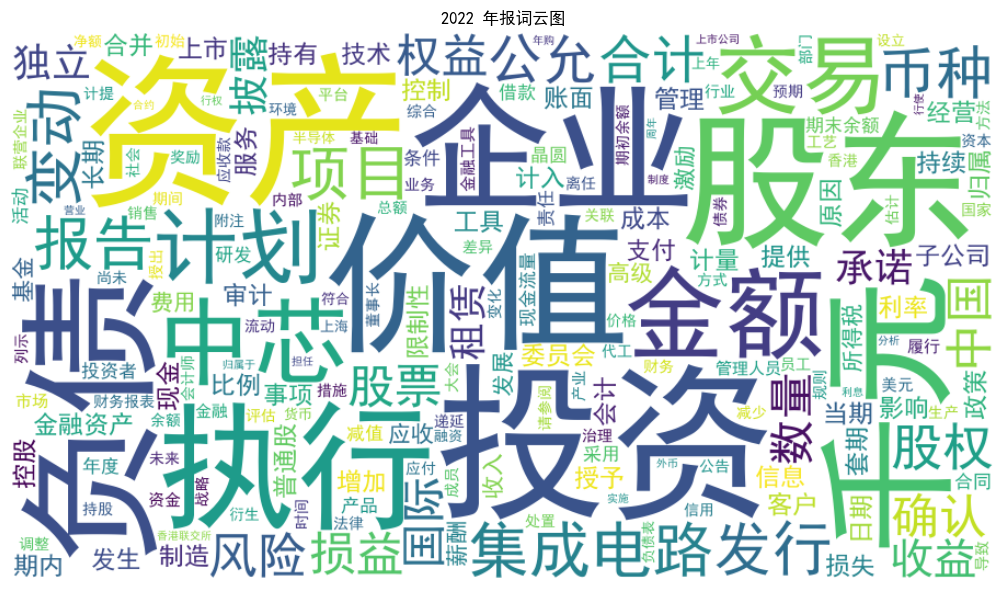

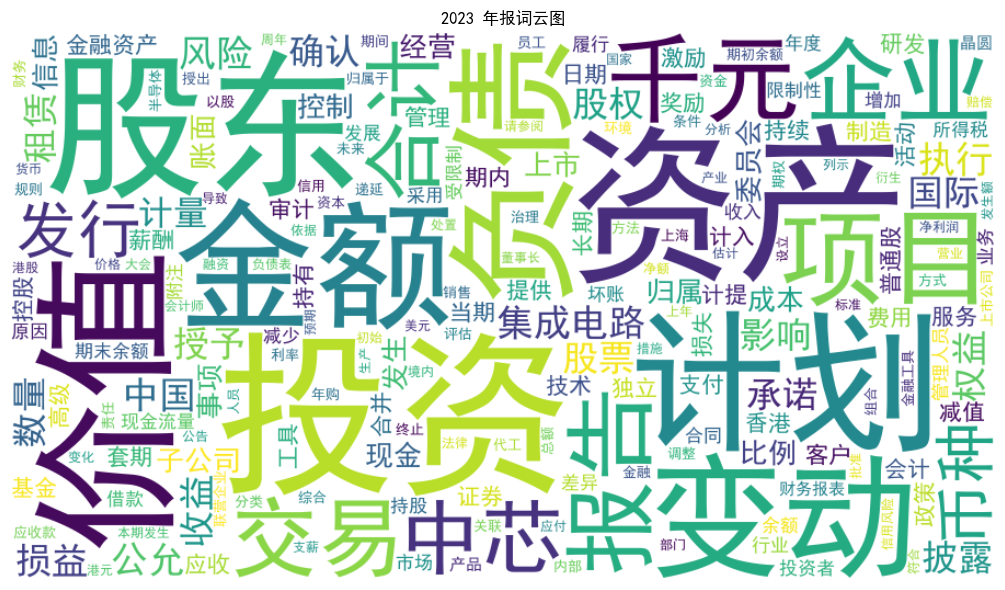

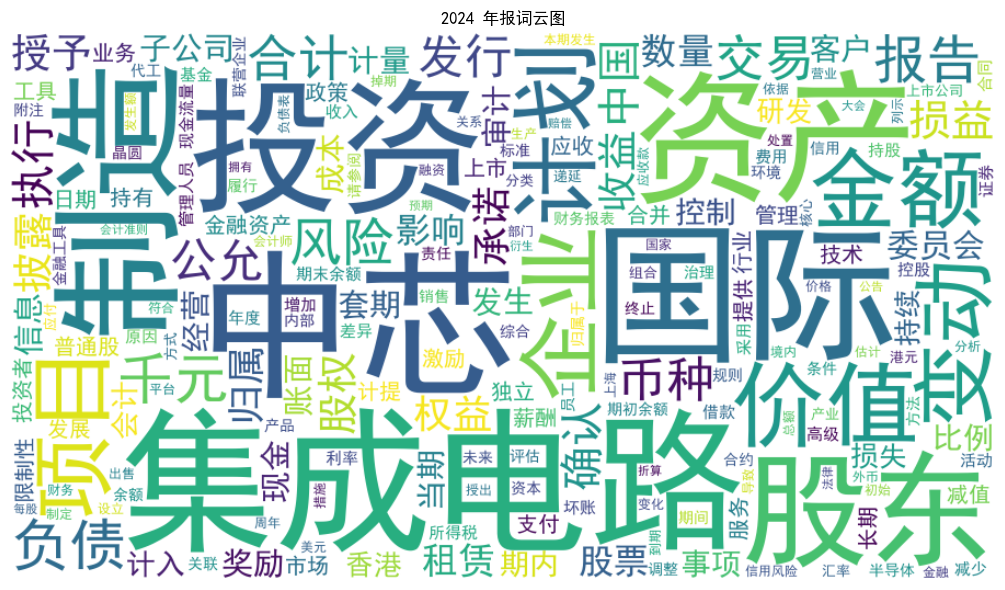

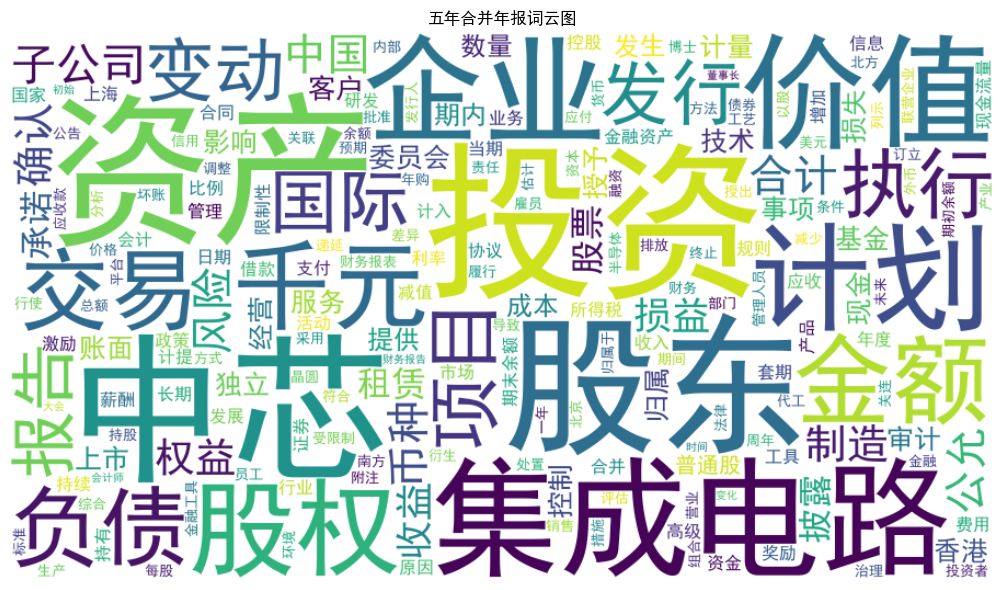

In [81]:
# 图像保存目录
fig_dir = "annual_reports/data/fig"
os.makedirs(fig_dir, exist_ok=True)

# 读取停用词
with open("annual_reports/data/stopwords.txt", "r", encoding="utf-8") as f:
    stopwords = set([line.strip() for line in f if line.strip()])

def tokenize(text):
    text = re.sub(r"[a-zA-Z0-9]+", " ", text)
    text = re.sub(r"[^\u4e00-\u9fa5]+", " ", text)
    words = jieba.lcut(text)
    return [w for w in words if len(w) >= 2 and w not in stopwords]

def make_wordcloud(words, title, save_path):
    freqs = dict(Counter(words))

    wc = WordCloud(
        font_path="C:/Windows/Fonts/simhei.ttf",  # ⭐直接写死
        width=900,
        height=500,
        background_color="white"
    ).generate_from_frequencies(freqs)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

# 逐年词云
txt_dir = "annual_reports/data/txt"
txt_files = sorted([f for f in os.listdir(txt_dir) if f.endswith(".txt")])

all_words = []

for fname in txt_files:
    year = fname.replace(".txt", "")
    with open(os.path.join(txt_dir, fname), "r", encoding="utf-8") as f:
        text = f.read()

    words = tokenize(text)
    all_words.extend(words)

    save_path = os.path.join(fig_dir, f"wordcloud_{year}.png")
    make_wordcloud(words, f"{year} 年报词云图", save_path)

# 五年合并词云
make_wordcloud(
    all_words,
    "五年合并年报词云图",
    os.path.join(fig_dir, "wordcloud_all_5y.png")
)

## 提取MD&A计算情感

In [49]:
import os
import re

# ===== 0) 路径 =====
txt_dir = "annual_reports/data/txt"          # 你的全文txt目录
out_dir = "annual_reports/data/mdna_txt"     # 输出MD&A目录
os.makedirs(out_dir, exist_ok=True)

txt_files = sorted([f for f in os.listdir(txt_dir) if f.endswith(".txt")])

# ===== 1) 文本归一化：去空格/换行/制表符（让标题更好匹配）=====
def normalize_text(text: str) -> str:
    # 把所有空白都去掉：空格、换行、tab、全角空格等
    return re.sub(r"\s+", "", text)

# ===== 2) 提取MD&A：按“起始章节标题”到“下一章节标题”截取 =====
def extract_mdna_by_sections(text_norm: str, year: str) -> str:
    """
    用“章节标题区间”截取：
    - 2020：第五节经营情况讨论与分析 → 第六节董事会报告
    - 2021-2024：第四节管理层讨论与分析 → 第五节董事会报告
    """
    if year == "2020":
        start_patterns = ["第五节经营情况讨论与分析", "第五节经营情况讨论与分析"]  # 保留两行是为了教学可读
        end_patterns   = ["第六节董事会报告"]
    else:
        start_patterns = ["第四节管理层讨论与分析", "第四节管理层讨论及分析"]
        end_patterns   = ["第五节董事会报告"]

    # 1) 找起点（取第一次出现）
    start_idx = -1
    for p in start_patterns:
        idx = text_norm.find(p)
        if idx != -1:
            start_idx = idx
            break
    if start_idx == -1:
        return ""

    sub_text = text_norm[start_idx:]

    # 2) 找终点（在sub_text里找最早出现的“下一章节标题”）
    end_idx = len(sub_text)
    for p in end_patterns:
        idx = sub_text.find(p)
        if idx != -1:
            end_idx = min(end_idx, idx)

    return sub_text[:end_idx]

# ===== 3) 批量提取 + 保存 =====
print("===== 开始提取 MD&A（按章节区间，先归一化再截取）=====")

mdna_texts = {}

for fname in txt_files:
    year = fname.replace(".txt", "")
    in_path = os.path.join(txt_dir, fname)

    with open(in_path, "r", encoding="utf-8") as f:
        full_text = f.read()

    full_norm = normalize_text(full_text)
    mdna_norm = extract_mdna_by_sections(full_norm, year)

    mdna_texts[year] = mdna_norm

    # 保存到文件（后续情感分析直接读这个更干净）
    out_path = os.path.join(out_dir, f"{year}_mdna.txt")
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(mdna_norm)

    print(f"{year} MD&A 字符数：{len(mdna_norm)}  | 已保存：{out_path}")

print("===== 提取完成 =====\n")

# ===== 4) 快速验收：每年前200字 =====
print("===== 快速验收（每年前200字）=====")
for year in sorted(mdna_texts.keys()):
    preview = mdna_texts[year][:200]
    print(f"\n【{year}】预览：\n{preview if preview else '（空）'}")

===== 开始提取 MD&A（按章节区间，先归一化再截取）=====
2020 MD&A 字符数：1470  | 已保存：annual_reports/data/mdna_txt\2020_mdna.txt
2021 MD&A 字符数：1429  | 已保存：annual_reports/data/mdna_txt\2021_mdna.txt
2022 MD&A 字符数：1177  | 已保存：annual_reports/data/mdna_txt\2022_mdna.txt
2023 MD&A 字符数：1166  | 已保存：annual_reports/data/mdna_txt\2023_mdna.txt
2024 MD&A 字符数：1194  | 已保存：annual_reports/data/mdna_txt\2024_mdna.txt
===== 提取完成 =====

===== 快速验收（每年前200字）=====

【2020】预览：
第五节经营情况讨论与分析”之“二、风险因素”。三、公司全体董事出席董事会会议。四、普华永道中天会计师事务所（特殊普通合伙）为本公司出具了标准无保留意见的审计报告。五、公司负责人周子学、主管会计工作负责人高永岗及会计机构负责人（会计主管人员）刘晨健声明：保证年度报告中财务报告的真实、准确、完整。六、经董事会审议的报告期利润分配方案或公积金转增股本预案公司2020年度拟不进行利润分配，该议案尚需提交2

【2021】预览：
第四节管理层讨论与分析”之“四、风险因素”。四、公司全体董事出席董事会会议。五、安永华明会计师事务所（特殊普通合伙）为本公司出具了标准无保留意见的审计报告。六、公司负责人高永岗、主管会计工作负责人高永岗及会计机构负责人（会计主管人员）刘晨健声明：保证年度报告中财务报告的真实、准确、完整。七、董事会决议通过的本报告期利润分配预案或公积金转增股本预案公司2021年度拟不进行利润分配，该议案尚需提交20

【2022】预览：
第四节管理层讨论与分析”之“四、风险因素”。四、公司全体董事出席董事会会议。五、安永华明会计师事务所（特殊普通合伙）为本公司出具了标准无保留意见的审计报告。六、公司负责人高永岗、主管会计工作负责人吴俊峰及会计机构负责人（会计主管人员）刘晨健声明：保证年度报告中财务报告的真实、准确、

In [50]:
# 准备情感词典
# 情感词典所在目录
sentiment_dir = "annual_reports/data/dict"   # ← 按你的实际路径改

# 读取正向词
with open(os.path.join(sentiment_dir, "positive.txt"), "r", encoding="gbk") as f:
    positive_words = set(line.strip() for line in f if line.strip())

# 读取负向词
with open(os.path.join(sentiment_dir, "negative.txt"), "r", encoding="gbk") as f:
    negative_words = set(line.strip() for line in f if line.strip())

print("正向词数量：", len(positive_words))
print("负向词数量：", len(negative_words))

# 看几条确认一下
print("正向词示例：", list(positive_words)[:10])
print("负向词示例：", list(negative_words)[:10])

正向词数量： 268
负向词数量： 190
正向词示例： ['一流', '旺季', '优于', '加快', '不懈努力', '收入', '提高', '完善', '充分发挥', '关键技术']
负向词示例： ['迎难而上', '管控', '趋缓', '跌幅', '停产', '整治', '尚未', '成本上升', '瓶颈', '成本费用']


In [51]:
# 计算 MD&A 年度情感指数

def sentiment_score(text, pos_words, neg_words):
    words = jieba.lcut(text)
    pos_cnt = sum(1 for w in words if w in pos_words)
    neg_cnt = sum(1 for w in words if w in neg_words)

    if pos_cnt + neg_cnt == 0:
        return 0, pos_cnt, neg_cnt

    score = (pos_cnt - neg_cnt) / (pos_cnt + neg_cnt)
    return score, pos_cnt, neg_cnt

rows = []

for year, text in mdna_texts.items():
    score, pos_cnt, neg_cnt = sentiment_score(
        text, positive_words, negative_words
    )
    rows.append([year, score, pos_cnt, neg_cnt, len(text)])

sentiment_df = pd.DataFrame(
    rows,
    columns=["year", "sentiment", "pos_count", "neg_count", "mdna_length"]
).sort_values("year")

print(sentiment_df)

   year  sentiment  pos_count  neg_count  mdna_length
0  2020  -0.238095          8         13         1470
1  2021  -0.238095          8         13         1429
2  2022  -0.333333          7         14         1177
3  2023  -0.300000          7         13         1166
4  2024  -0.300000          7         13         1194


In [52]:
def calc_sentiment(text, pos_set, neg_set):
    # 分词
    words = jieba.lcut(text)

    # 计数
    pos_cnt = sum(1 for w in words if w in pos_set)
    neg_cnt = sum(1 for w in words if w in neg_set)

    # 情感指数：[-1, 1]
    if pos_cnt + neg_cnt == 0:
        score = 0
    else:
        score = (pos_cnt - neg_cnt) / (pos_cnt + neg_cnt)

    # 占比（便于解释）
    total = pos_cnt + neg_cnt
    pos_ratio = pos_cnt / total if total > 0 else 0
    neg_ratio = neg_cnt / total if total > 0 else 0

    return score, pos_cnt, neg_cnt, pos_ratio, neg_ratio

rows = []
for year, text in mdna_texts.items():
    score, pos_cnt, neg_cnt, pos_ratio, neg_ratio = calc_sentiment(
        text, positive_words, negative_words
    )
    rows.append([year, len(text), pos_cnt, neg_cnt, pos_ratio, neg_ratio, score])

sent_df = pd.DataFrame(rows, columns=[
    "year", "mdna_chars", "pos_cnt", "neg_cnt", "pos_ratio", "neg_ratio", "sentiment"
]).sort_values("year")

print(sent_df)

   year  mdna_chars  pos_cnt  neg_cnt  pos_ratio  neg_ratio  sentiment
0  2020        1470        8       13   0.380952   0.619048  -0.238095
1  2021        1429        8       13   0.380952   0.619048  -0.238095
2  2022        1177        7       14   0.333333   0.666667  -0.333333
3  2023        1166        7       13   0.350000   0.650000  -0.300000
4  2024        1194        7       13   0.350000   0.650000  -0.300000


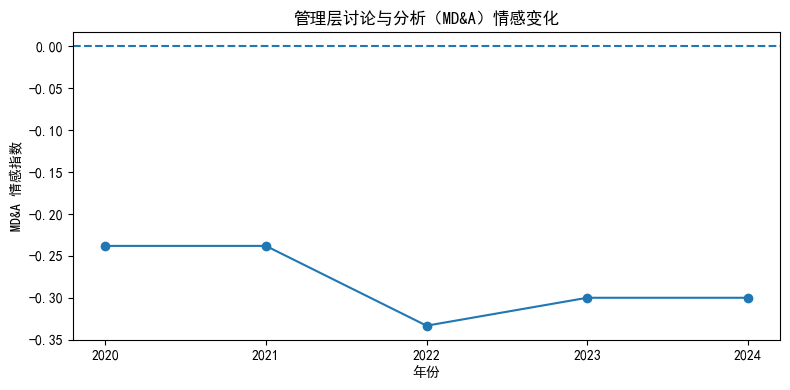

In [53]:
# 情感指数折线图

plt.figure(figsize=(8, 4))
plt.plot(sentiment_df["year"], sentiment_df["sentiment"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("年份")
plt.ylabel("MD&A 情感指数")
plt.title("管理层讨论与分析（MD&A）情感变化")
plt.tight_layout()
plt.show()

In [54]:
# 拐点年份的“文本证据”
# 找情感最低的年份（示例）
worst_year = sentiment_df.sort_values("sentiment").iloc[0]["year"]
print("情感最低年份：", worst_year)

text = mdna_texts[str(worst_year)]

# 简单截取包含“风险/不确定”的句子作为证据
sentences = re.split("。|；", text)
evidence = [s for s in sentences if ("风险" in s or "不确定" in s)]

print("\n文本证据示例（最多3条）：")
for s in evidence[:3]:
    print("-", s[:40])

情感最低年份： 2022

文本证据示例（最多3条）：
- 第四节管理层讨论与分析”之“四、风险因素”
- 八、是否存在公司治理特殊安排等重要事项√适用□不适用公司治理特殊安排情况：√本公
- 该等前瞻性陈述乃反映中芯国际高级管理层根据最佳判断作出的估计，存在重大已知及未知


In [ ]:
# 只计算2020年和2024年

In [59]:
import os, re

txt_path_2020 = "annual_reports/data/txt/2020.txt"
out_path_2020 = "annual_reports/data/mdna_full/2020_mdna_full_2.txt"
os.makedirs(os.path.dirname(out_path_2020), exist_ok=True)

def normalize_text_keep_lines(text):
    text = text.replace("\u3000", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    return text

def find_last_match_start(text, pattern):
    ms = list(re.finditer(pattern, text))
    return ms[-1].start() if ms else -1

with open(txt_path_2020, "r", encoding="utf-8") as f:
    full_text = normalize_text_keep_lines(f.read())

# 2020：正文里通常是“第五节 经营情况讨论与分析”
start_pat = r"第\s*五\s*节\s*经\s*营\s*情\s*况\s*讨\s*论\s*与\s*分\s*析"

start_idx = find_last_match_start(full_text, start_pat)
if start_idx == -1:
    mdna_2020 = ""
else:
    # 先粗取一大段（固定长度，避免提前截断）
    mdna_2020 = full_text[start_idx : start_idx + 80000]

    # 再尝试用“下一章标题”截断（截到更干净；截不到也没关系）
    end_pat = r"第\s*六\s*节|第\s*6\s*节"
    m = re.search(end_pat, mdna_2020[50:])
    if m:
        mdna_2020 = mdna_2020[:50 + m.start()]

with open(out_path_2020, "w", encoding="utf-8") as f:
    f.write(mdna_2020)

print("2020 完整MD&A 字符数：", len(mdna_2020))
print("已保存：", out_path_2020)
print("\n前200字预览：\n", mdna_2020[:200].replace("\n", " "))


2020 完整MD&A 字符数： 24263
已保存： annual_reports/data/mdna_full/2020_mdna_full_2.txt

前200字预览：
 第五节经营情况讨论与分析”之“三、（五）投资状况分析”。 6、 其他 □适用 √不适用 229 / 256 2020年年度报告 九、 在其他主体中的权益 1、 在子公司中的权益 (1). 企业集团的构成 √适用 □不适用 取得 子公司 持股比例(%) 主要经营地 注册地 业务性质 方式 名称 直接 间接 柏途企业有限公司 萨摩亚 萨摩亚 提供市场推广 100.00% 投资 相关活动 设立 中芯国际


In [60]:
import os, re

txt_path_2024 = "annual_reports/data/txt/2024.txt"
out_path_2024 = "annual_reports/data/mdna_full/2024_mdna_full_2.txt"
os.makedirs(os.path.dirname(out_path_2024), exist_ok=True)

def normalize_text_keep_lines(text):
    text = text.replace("\u3000", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    return text

def find_last_match_start(text, pattern):
    ms = list(re.finditer(pattern, text))
    return ms[-1].start() if ms else -1

with open(txt_path_2024, "r", encoding="utf-8") as f:
    full_text = normalize_text_keep_lines(f.read())

# 2024：目录显示“第四节 管理层讨论与分析”（更常见）
start_pat = r"第\s*四\s*节\s*管\s*理\s*层\s*讨\s*论\s*(与|及|和)\s*分\s*析"

start_idx = find_last_match_start(full_text, start_pat)
if start_idx == -1:
    mdna_2024 = ""
else:
    mdna_2024 = full_text[start_idx : start_idx + 80000]

    # 尝试用“下一章标题”截断（更干净）
    end_pat = r"第\s*五\s*节|第\s*5\s*节"
    m = re.search(end_pat, mdna_2024[50:])
    if m:
        mdna_2024 = mdna_2024[:50 + m.start()]

with open(out_path_2024, "w", encoding="utf-8") as f:
    f.write(mdna_2024)

print("2024 完整MD&A 字符数：", len(mdna_2024))
print("已保存：", out_path_2024)
print("\n前200字预览：\n", mdna_2024[:200].replace("\n", " "))

2024 完整MD&A 字符数： 80000
已保存： annual_reports/data/mdna_full/2024_mdna_full_2.txt

前200字预览：
 第四节管理层讨论与分析”之“二、报告期内公司所从 事的主要业务、经营模式、行业情况及研发情况说明”。 (三)遵守科技伦理情况 中芯国际作为集成电路制造企业，主要业务是为客户提供芯片制造服务。报告期内，公司主 营业务未涉及科技伦理敏感方向的科研活动。尽管如此，我们仍以审慎态度持续关注科技伦理的 全球治理动态，严格遵守科技伦理相关要求。 (四)数据安全与隐私保护情况 中芯国际将信息安全与客户隐私保护置
